## 4.5 极大投影设计

最大最小设计以填充 $p$ 维空间为核心目标，但研究发现，这类设计映射至低维子空间时往往会产生不理想的投影效果。为解决该问题，研究人员将最大最小设计的范围限定为拉丁超立方设计（LHD），以此保证一维投影具备良好特性。然而，最大最小拉丁超立方设计（MmLHD）映射至维度为 $2, \dots, p-1$ 的子空间时，投影效果依旧可能较差。德拉古利奇等人（2012年）遍历全部子空间计算式 (4.18) 中的 TRD 准则，试图改善最大最小拉丁超立方设计的投影特性。子空间总数满足：$p+\binom{p}{2}+\dots+\binom{p}{p-1}=2^p-2$。当 $p$ 取值较大时，子空间数量十分庞大，致使基于 TRD 准则的优化计算量激增，难以实现求解。

该问题的另一种构建方式是为每个变量引入权重，并将准则修改为：

$$
TRD_w(D)=\sum_{i=1}^{n}\sum_{j\neq i}\frac{1}{\{\sum_{k=1}^{p}w_k(x_{ik}-x_{jk})^2\}^\alpha}
$$

式中满足 $w_i \ge 0$（$i=1,\dots,p$），且 $\sum_{i=1}^{p}w_i = 1$。举例来说，若已知变量 $x_1$、$x_2$ 具备重要作用，便可令 $w_1=w_2=\frac12$，其余权重 $w_i$ 全部置为 0。但难点在于，在设计阶段无法预知哪些变量是重要变量。解决该问题的一种方法是采用贝叶斯方法：先为权重向量 $\boldsymbol{w}=(w_1,\dots,w_{p-1})^\prime$ 设定先验分布，再在权重 $\boldsymbol{w}$ 的所有可行取值上对 $TRD_w(D)$ 求平均。

假设我们事先并不知晓各变量的重要程度，那么对权重 $\boldsymbol{w}$ 赋予均匀先验分布是合理的：

$$
f(\boldsymbol{w}) = (p - 1)!，\quad \boldsymbol{w} \in \mathcal{W} = \left\{\boldsymbol{w}:\boldsymbol{w} \ge 0,\sum_{i=1}^{p-1} w_i \le 1\right\}
\tag{4.22}
$$

于是可得：

$$
\int_{\mathcal{W}} TRD_w(D)f(\boldsymbol{w})d\boldsymbol{w} = \sum_{i=1}^n\sum_{j\ne i}\int_{\mathcal{W}} \frac{1}{\left\{\sum_{k=1}^p w_k(x_{ik}-x_{jk})^2\right\}^\alpha} f(\boldsymbol{w})d\boldsymbol{w}
$$

高维积分的计算成本通常较高，但可以注意到，当 $\alpha = p = 2$ 时，能够求得解析解：

$$
\int_0^1 \frac{1}{\left[w_1(x_{i1}-x_{j1})^2 + (1-w_1)(x_{i2}-x_{j2})^2\right]^2}dw_1 = \frac{1}{(x_{i1}-x_{j1})^2(x_{i2}-x_{j2})^2}
$$

借助数学归纳法即可证明下述结论（约瑟夫等人，2015）。

> **定理 4.3** 若 $\alpha=p$，则在式 (4.22) 的先验分布条件下，
> $$\int_{\mathcal{W}}\frac{1}{\{\sum_{k=1}^{p}w_{k}(x_{ik}-x_{jk})^{2}\}^{\alpha}}f(\boldsymbol{w})d\boldsymbol{w}=\frac{1}{\prod_{k=1}^{p}(x_{ik}-x_{jk})^{2}}$$

因此，设计准则为

$$
\min_D \sum_{i=1}^n \prod_{j \neq i}\frac{1}{\sum_{k=1}^p (x_{ik}-x_{jk})^2}
\tag{4.23}
$$

由于该准则能够最大化设计的投影能力，约瑟夫等人（2015）将其命名为最大投影（MaxPro）设计。该准则的计算复杂度并未高于式 (4.18) 中的截断随机设计（TRD）准则，仅是将分母中的求和运算替换为连乘运算。连乘项能够保证任意两个坐标互不相等，因此该准则可自动满足拉丁超立方设计的约束条件。

下面给出最大投影（MaxPro）准则的另一层论证：假定选取式(2.11)中的各向异性高斯相关函数，并搭配无信息先验分布：$f(\theta_k) \propto 1/\theta_k^3$，其中 $k = 1, \dots, p$，则：

$$
\begin{align*}
E\{\|\boldsymbol{R} - \boldsymbol{I}_n\|_1\}&\propto\sum_{i=1}^{n}\sum_{j\neq i}\int\exp\left(-\sum_{k=1}^{p}\frac{(x_{ik}-x_{jk})^2}{\theta_k^2}\right)\prod_{k=1}^{p}\frac{1}{\theta_k^3}d\boldsymbol{\theta}
\tag{4.24}\\
&=\sum_{i=1}^{n}\sum_{j\neq i}\prod_{k=1}^{p}\int\exp\left(-\frac{(x_{ik}-x_{jk})^2}{\theta_k^2}\right)\frac{1}{\theta_k^3}d\theta_k\\
&\propto\sum_{i=1}^{n}\sum_{j\neq i}\frac{1}{\prod_{k=1}^{p}(x_{ik}-x_{jk})^2}
\end{align*}
$$

由此可见，各向同性高斯相关函数对应极大极小准则；而在尺度参数上配置无信息先验的各向异性高斯相关函数，则对应最大投影准则。分母中的连乘项并非严格意义上的距离度量，但可看作闵可夫斯基距离取极限的结果（约瑟夫等人，2019）：

$$
\lim_{\alpha\to0}\frac{\|\boldsymbol{x}_i-\boldsymbol{x}_j\|_\alpha}{p^{1/\alpha}}=\left(\prod_{k=1}^{p}|x_{ik}-x_{jk}|\right)^{1/p}
\tag{4.25}
$$

也就是说，若选取极小的 $\alpha$，结合闵可夫斯基距离度量并依据式 (4.16) 构造极大极小设计，最终得到的设计会近似于最大投影设计。

还可以借助有理二次核的乘积形式，进一步说明最大投影（MaxPro）设计的合理性：

$$
R(\boldsymbol{\Delta})=\prod_{k=1}^{p}\left(1+\frac{\Delta_k^2}{\theta_k^2}\right)^{-1}
\tag{4.26}
$$

于是有：

$$
\begin{aligned}
\|\boldsymbol{R}-\boldsymbol{I}_n\|_1&=\sum_{i=1}^{n}\sum_{j\neq i}\prod_{k=1}^{p}\left(1+\frac{(x_{ik}-x_{jk})^2}{\theta_k^2}\right)^{-1}\\
&=\prod_{k=1}^{p}\theta_k^{2p}\sum_{i=1}^{n}\sum_{j\neq i}\prod_{k=1}^{p}\frac{1}{\theta_k^2+(x_{ik}-x_{jk})^2}\\
&\leq\prod_{k=1}^{p}\theta_k^{2p}\sum_{i=1}^{n}\sum_{j\neq i}\frac{1}{\sum_{k=1}^{p}(x_{ik}-x_{jk})^2}
\end{aligned}
$$

对于任意取值的参数 $\boldsymbol{\theta}$，该式均可在采用最大投影设计时取得最小值。

约瑟夫等人（2015）提出一种基于梯度的优化方法来构造极大投影（MaxPro）设计，式 (4.23) 中目标函数关于 $x_{rs}$ 的梯度表达式为：

$$
\frac{\partial}{\partial x_{rs}}\left\{\sum_{i=1}^{n}\sum_{j\neq i} \frac{1}{\prod_{k=1}^{p}(x_{ik}-x_{jk})^2}\right\}=4\sum_{i\neq r} \frac{1}{\prod_{k=1}^{p}(x_{ik}-x_{rk})^2} \cdot \frac{1}{(x_{is}-x_{rs})}
$$

但该目标函数存在大量局部最优解，想要求得全局最优解就需要设置大量随机初始点。为避免多次随机初始化寻优，他们借鉴莫里斯与米切尔（1995）所用算法，提出采用模拟退火算法先构造极大投影拉丁超立方设计（MaxPro LHD），再开展梯度优化。该方法已在 R 语言程序包 MaxPro 中实现（巴、约瑟夫，2018）。R 程序包 SFDesign（王、约瑟夫，2025c）采用了相同思路，并在模拟退火阶段结束后额外增加一步确定性优化，优化效果有所提升。维度 $p=2$、样本量分别为 7 和 20 的极大投影设计结果如图 4.10 所示。可以观察到这类设计能够很好地填充整个空间，同时具备拉丁超立方结构；但各坐标轴上的采样点不再像普通拉丁超立方设计那样均匀分布。样本点会向区域边界靠拢，不过聚拢程度低于图 4.9 中切比雪夫变换的效果。

> **图 4.10**：维度 $p=2$、样本量 $n=7$（左图）与 $n=20$（右图）对应的极大投影（MaxPro）设计。

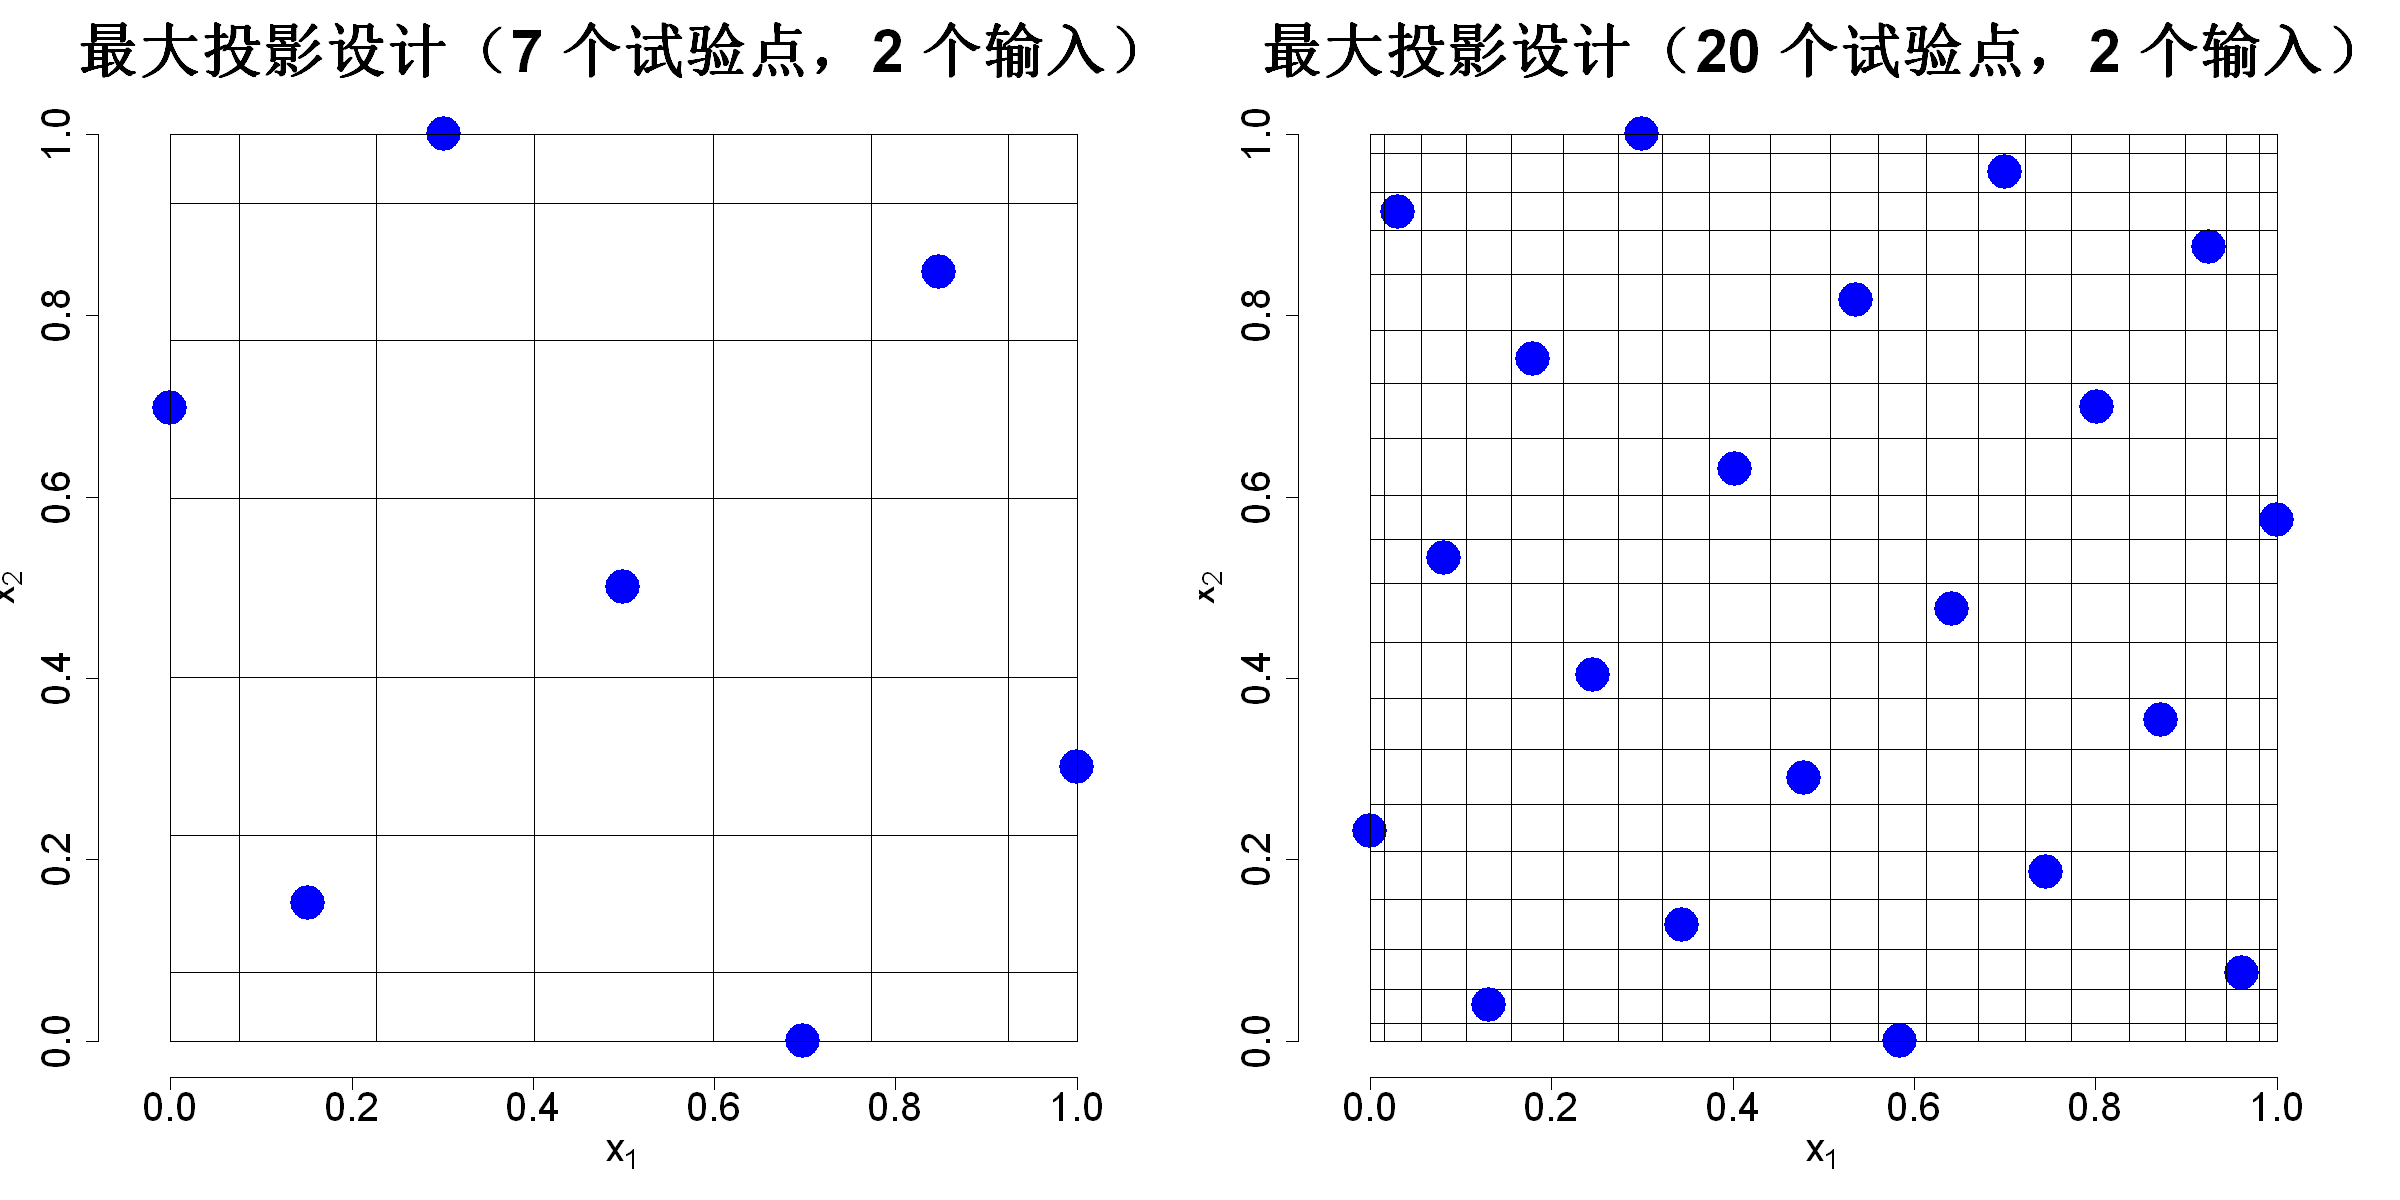

In [2]:
options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
p=2;n=7
set.seed(1)
library(SFDesign)
D=maxpro.optim(maxproLHD(n,p)$design)$design
plot(D,pch=16,cex=4,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,main="最大投影设计（7 个试验点，2 个输入）",cex.main=3,asp=1)
d1=sort(D[,1])
l1=c(0,(d1[-1]+d1[-n])/2,1)
d2=sort(D[,2])
l2=c(0,(d2[-1]+d2[-n])/2,1)
for(i in 1:(n+1)){
segments(l1[i],0,l1[i],1)
segments(0,l2[i],1,l2[i])
}

p=2;n=20
D=maxpro.optim(maxproLHD(n,p)$design)$design
plot(D,pch=16,cex=4,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,main="最大投影设计（20 个试验点，2 个输入）",cex.main=3,asp=1)
d1=sort(D[,1])
l1=c(0,(d1[-1]+d1[-n])/2,1)
d2=sort(D[,2])
l2=c(0,(d2[-1]+d2[-n])/2,1)
for(i in 1:(n+1)){
segments(l1[i],0,l1[i],1)
segments(0,l2[i],1,l2[i])
}
par(mfrow=c(1,1))

高维设计难以直观可视化。为此，图 4.11 以散点矩阵形式展示了五维、样本量 $n=50$ 的极大投影设计各样本点的二维投影。可以观察到，样本点在各个二维投影中分布均匀舒展。图 4.12 绘制了极大投影设计与最大最小距离拉丁超立方设计（MmLHD），分别在一维、二维、三维、四维投影空间以及完整维度空间内，所有样本点两两最小距离的最小值变化曲线。不难看出，在完整维度空间中，最大最小距离拉丁超立方设计的最小距离更大，这一现象符合理论预期，因为该设计的构造思路本身就是在全维度空间内最大化样本点之间的最小距离。但将样本点投影至二维、三维或四维空间后，极大投影设计的最小距离反而更大。该特性具备实用价值，原因在于开展实验前，我们无法预知哪些维度属于关键维度。极大投影设计在一维投影中的最小距离小于最大最小距离拉丁超立方设计，原因是极大投影设计中有更多样本点靠近区域边界。总体而言，在维度为 2 至 $p-1$ 的投影空间里，极大投影设计的表现通常优于最大最小距离拉丁超立方设计，因此面对各变量重要程度未知的情况，极大投影设计具备更强的稳健性。

> **图 4.11** 样本量 $n=50$、维度 $p=5$ 的极大投影设计点散点矩阵图。

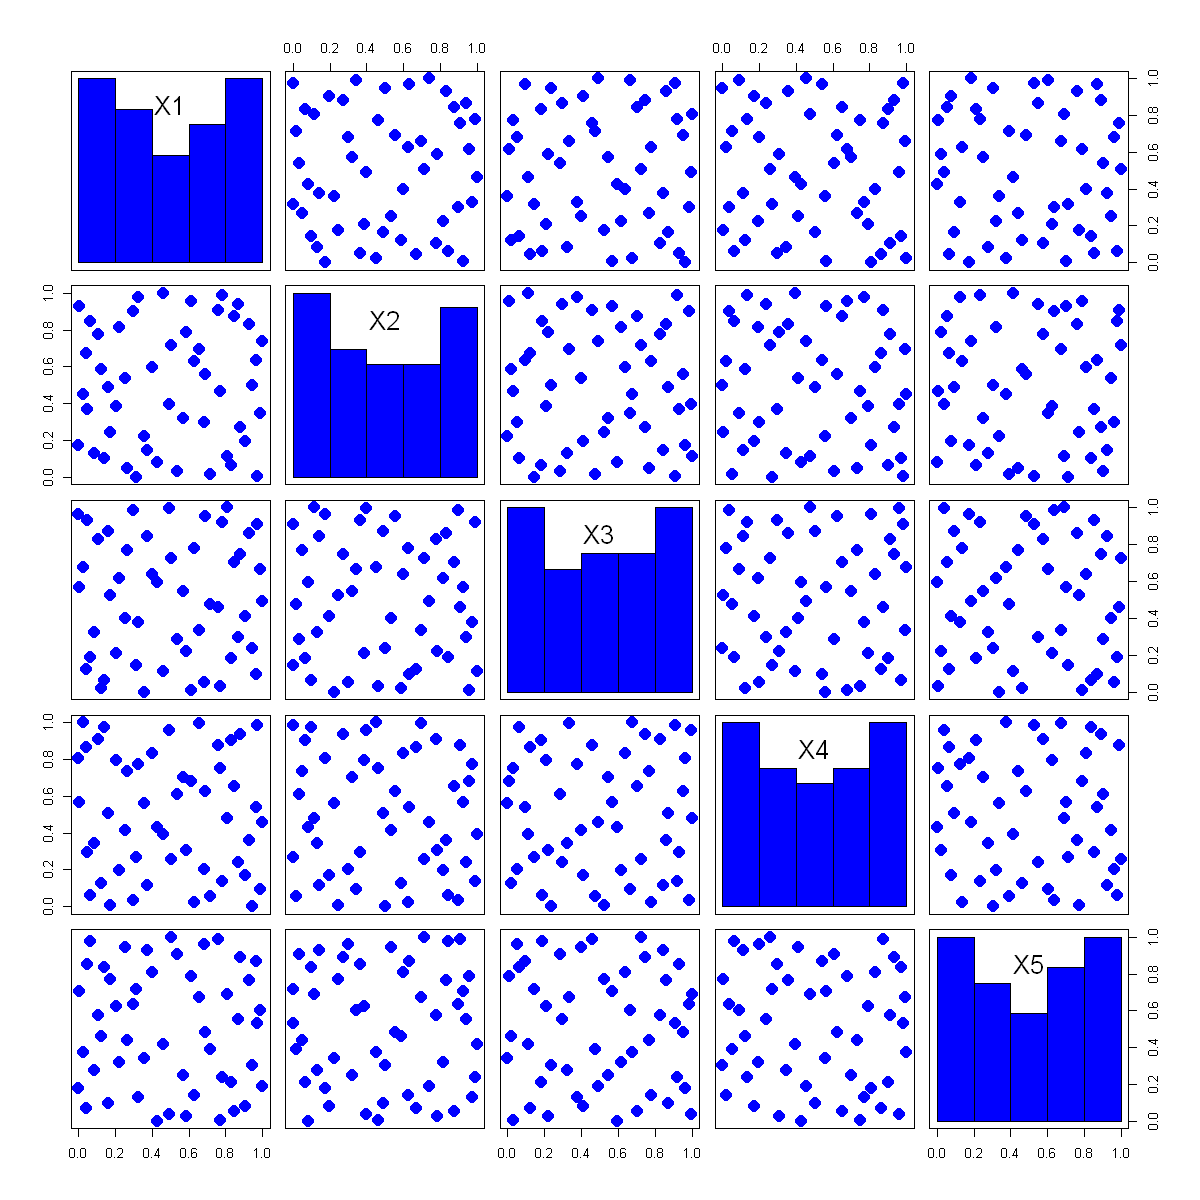

In [4]:
options(repr.plot.width=10,repr.plot.height=10)
p=5;n=50
set.seed(2)
library(SFDesign)
D=maxpro.optim(maxproLHD(n,p)$design)$design
library(car)
scatterplotMatrix(D,diagonal=list(method="histogram"),cex=2,smooth=FALSE,regLine=FALSE,pch=16)

> **图 4.12** 投影至子空间的各点之间最小距离的最小值。

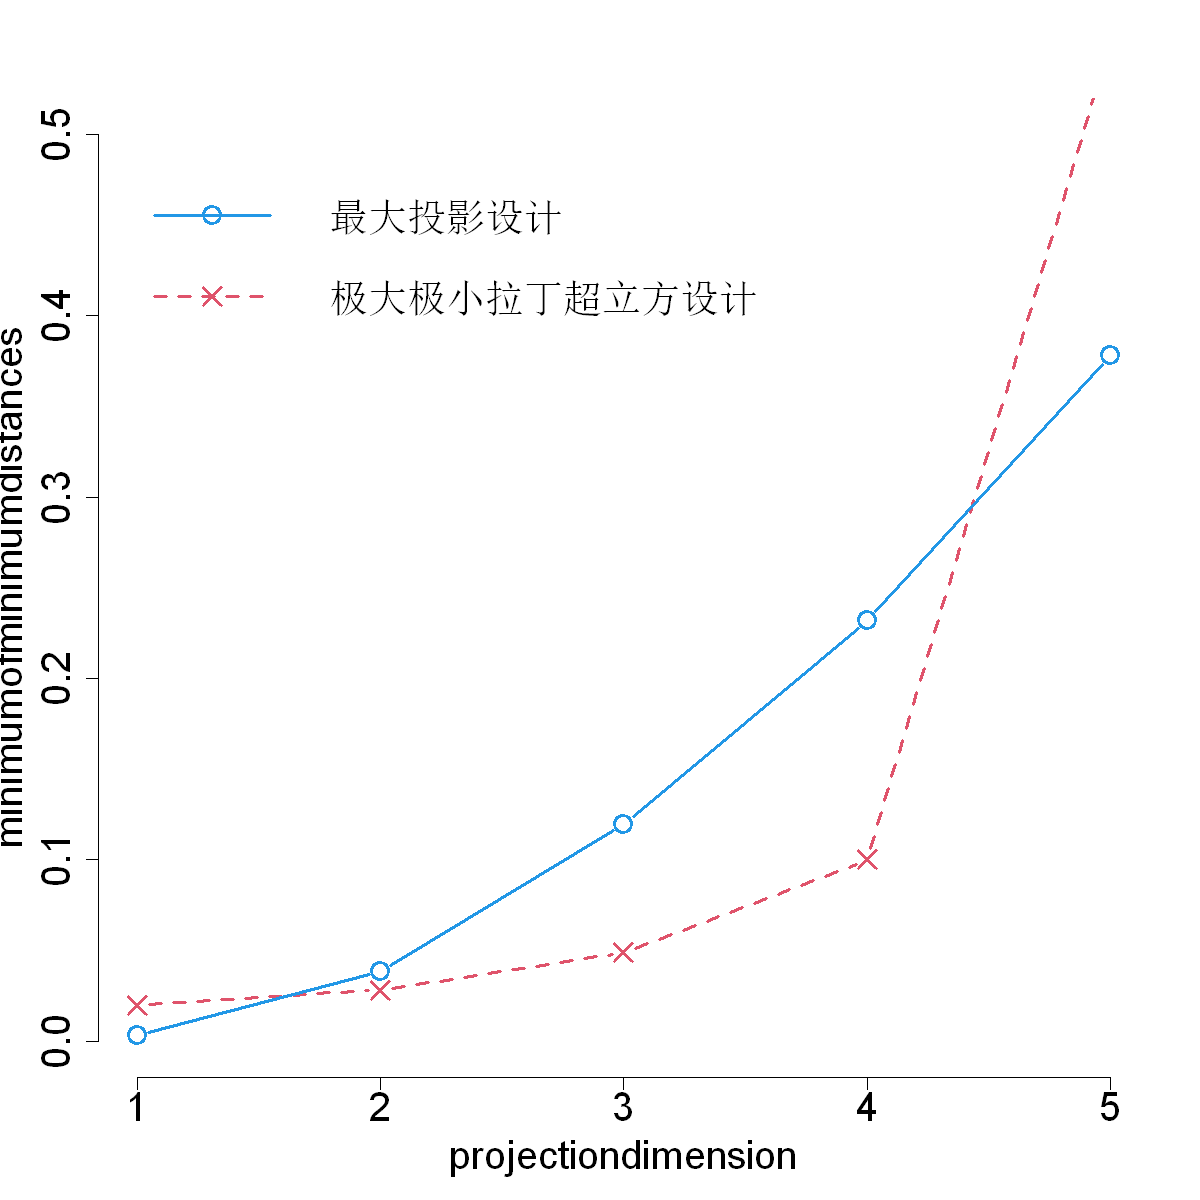

In [4]:
options(repr.plot.width=10,repr.plot.height=10)
p=5;n=50
set.seed(2)
library(SFDesign)
library(gtools)
D1=maximinLHD(n,p)$design
set.seed(2)
D2=maxpro.optim(maxproLHD(n,p)$design)$design

min_mindist=function(M){
    n=nrow(M)
    p=ncol(M)
    a=rep(0,p)
    for(j in 1:p){
        comb=combinations(p,j)
        k=nrow(comb)
        temp=rep(0,k)
        for(i in 1:k)temp[i]=min(dist(M[,comb[i,]]))
        a[j]=min(temp)
    }
    return(a)
}

d1=min_mindist(D1)
d2=min_mindist(D2)
matplot(1:p,cbind(d1,d2),type="b",pch=c(4,1),col=c(2,4),lty=c(2,1),bty="n",xlim=c(1,5),ylim=c(0,0.5),xlab="projectiondimension",ylab="minimumofminimumdistances",cex=2,cex.lab=2,cex.axis=2,lwd=3)
legend(1,.5,c("最大投影设计","极大极小拉丁超立方设计"),pch=c(1,4),lty=c(1,2),bty='n',lwd=3,col=c(4,2),cex=2)

张等人（2021）研究发现，小型极大极小设计（样本量与维度比值 $n_1/p$ 较小）不利于相关参数的估计，该现象是极大极小设计投影效果较差所造成的固有问题。图 4.13 展示了六维、64 次试验的极大极小设计样本点两两间距的直方图。由于 $64<2^6$，所有样本点都会被挤压至超立方体 $[0, 1]^6$ 的各个顶点处，最终仅存在少量互不相同的两两间距。该图同时给出了 64 次试验的最大投影（MaxPro）设计对应的样本两两间距分布。可以观察到最大投影设计的样本间距几乎呈连续分布，能够利用形状参数为 10.1 与 12.7 的缩放贝塔分布实现良好拟合。张等人（2021）通过实证研究证实：若试验设计的样本两两间距近似服从贝塔分布，该设计在相关参数估计中表现优异。据此他们提出了优化算法，用以生成两两间距分布贴合贝塔分布的试验设计，贝塔分布的形状参数由样本量 $n$ 与维度 $p$ 确定。尽管最大投影设计的设计初衷是保障预测效果，但该类设计的样本两两间距恰好天然具备贝塔分布特性，因此可以推断，最大投影设计在相关参数估计方面同样能取得优良效果。

> **图 4.13**：两组直方图分别展示 (64,6) 极大极小设计与 (64,6) 最大投影设计样本两两间距的分布；贝分布密度函数定义域缩放至 $[0,\sqrt6]$ 区间。

shape1   shape2 
10.08950 12.72548

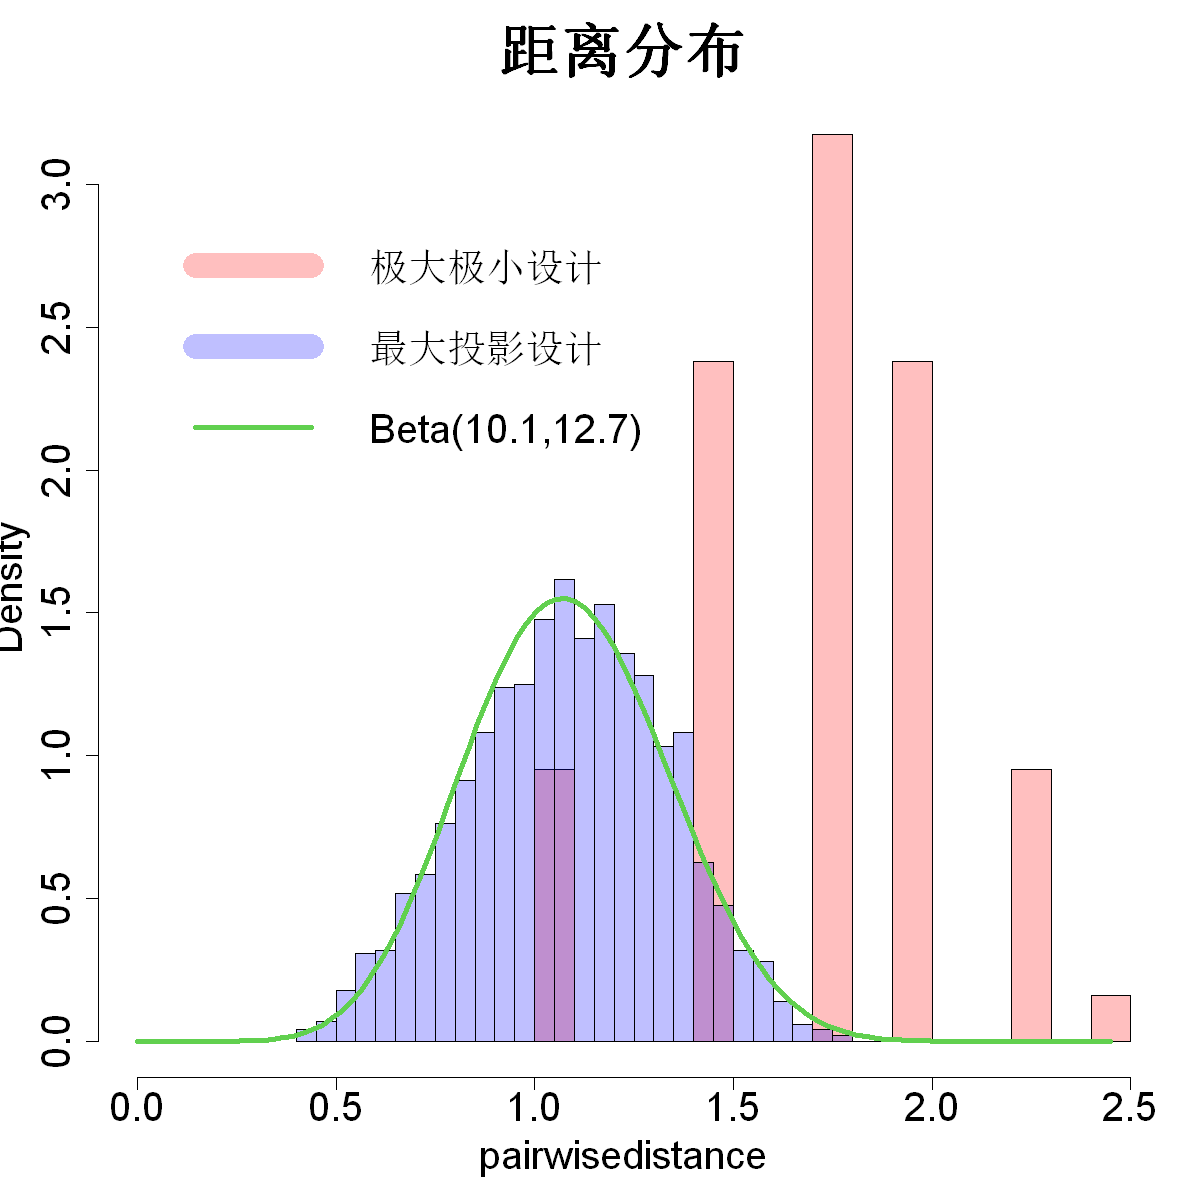

In [6]:
options(repr.plot.width=10,repr.plot.height=10)
p=6;n=64
set.seed(1)
library(SFDesign)
D1=maximin.optim(maximinLHD(n,p)$design,find.best.ini=TRUE)$design
D2=maxpro.optim(maxproLHD(n,p)$design)$design
d1=c(dist(D1))
d2=c(dist(D2))
library(fitdistrplus)
a=fitdist(d2/sqrt(p),"beta")
a$estimate
hist(d1,prob=TRUE,xlim=c(0,sqrt(p)),col=rgb(1,0,0,1/4),xlab="pairwisedistance",main="距离分布",cex.lab=2,cex.axis=2,cex.main=3)
hist(d2,prob=TRUE,col=rgb(0,0,1,1/4),breaks=30,add=TRUE)
curve(dbeta(x/sqrt(p),a$estimate[1],a$estimate[2])/sqrt(p),from=0,to=sqrt(p),add=TRUE,col=3,lwd=4)
legend(0,3,legend=c("极大极小设计","最大投影设计","Beta(10.1,12.7)"),col=c(rgb(1,0,0,1/4),rgb(0,0,1,1/4),3),lty=c(1,1,1),lwd=c(20,20,4),bty="n",cex=2)

相较于极大极小拉丁超立方设计（MmLHD），极大投影设计的一大显著优势在于：极大投影准则支持序贯构造试验设计。我们先选取 $x_1 \in X$，再按照下述方式逐个添加 $x_2,\dots,x_n$（约瑟夫，2016）：

$$
\boldsymbol{x}_{k+1}=\argmin_{\boldsymbol{x}\in \mathcal{X}}\sum_{i=1}^k\frac{1}{\prod_{j=1}^p(x_j-x_{ij})^2},\quad k=1,\dots,n-1
\tag{4.27}
$$

MaxPro 软件包中的 R 语言函数 MaxProAugment 可实现该构造方法（巴、约瑟夫，2018）。此种贪婪优化算法生成的设计，效果不及模拟退火算法与梯度优化算法构造的设计，但该方法灵活性强，能够解决多种不同类型的问题。

作为式 (4.27) 中序贯最大投影（MaxPro）构造方法的一项应用，我们考虑生成验证集以检验拟合模型拟合优度的问题。举例说明，选取仿真实验虚拟文库（苏尔雅诺维奇、宾厄姆，2013）中的二维布兰宁函数：

$$
f(x)=\left(x_2-\frac{5.1}{4\pi^2}x_1^2+\frac{5}{\pi}x_1-6\right)^2+10\left(1-\frac{1}{8\pi}\right)\cos x_1+10,\quad x_1\in[-5,10],\;x_2\in[0,15] \tag{4.28}
$$

将该函数定义域缩放至 $[0,1]^2$ 后对应的函数图像如图 4.14 左图所示，图中蓝色圆点代表包含 10 个样本点的最大投影设计。接下来借助式 (4.27) 额外生成 10 个样本点用作验证集，在同一张图中以红色三角形表示。本文利用 R 语言程序包 rkriging（黄、约瑟夫，2024）拟合普通克里金预测模型，并在验证集上计算均方根预测误差（RMSE）。作为对照，针对 100 组随机生成的 10 点验证集分别计算均方根预测误差，对应结果绘制为箱线图，见图 4.14 右图。不难发现，基于序贯最大投影方法构造的验证集所得均方根预测误差，高于箱线图上须的数值。原因在于：随机生成的验证集往往会包含靠近设计点的样本，这类样本易于预测，最终得到的均方根预测误差偏小；而序贯最大投影生成的验证样本在所有子空间内均远离设计点，由此构成的验证集预测难度更高。

> **图 4.14** 左侧图像展示了马克斯普罗设计样本（蓝色圆点）与通过序贯马克斯普罗方法生成的验证点（红色三角形）叠加在布拉宁函数图像上的效果。右侧图像为 100 组随机验证集均方根误差的箱线图。

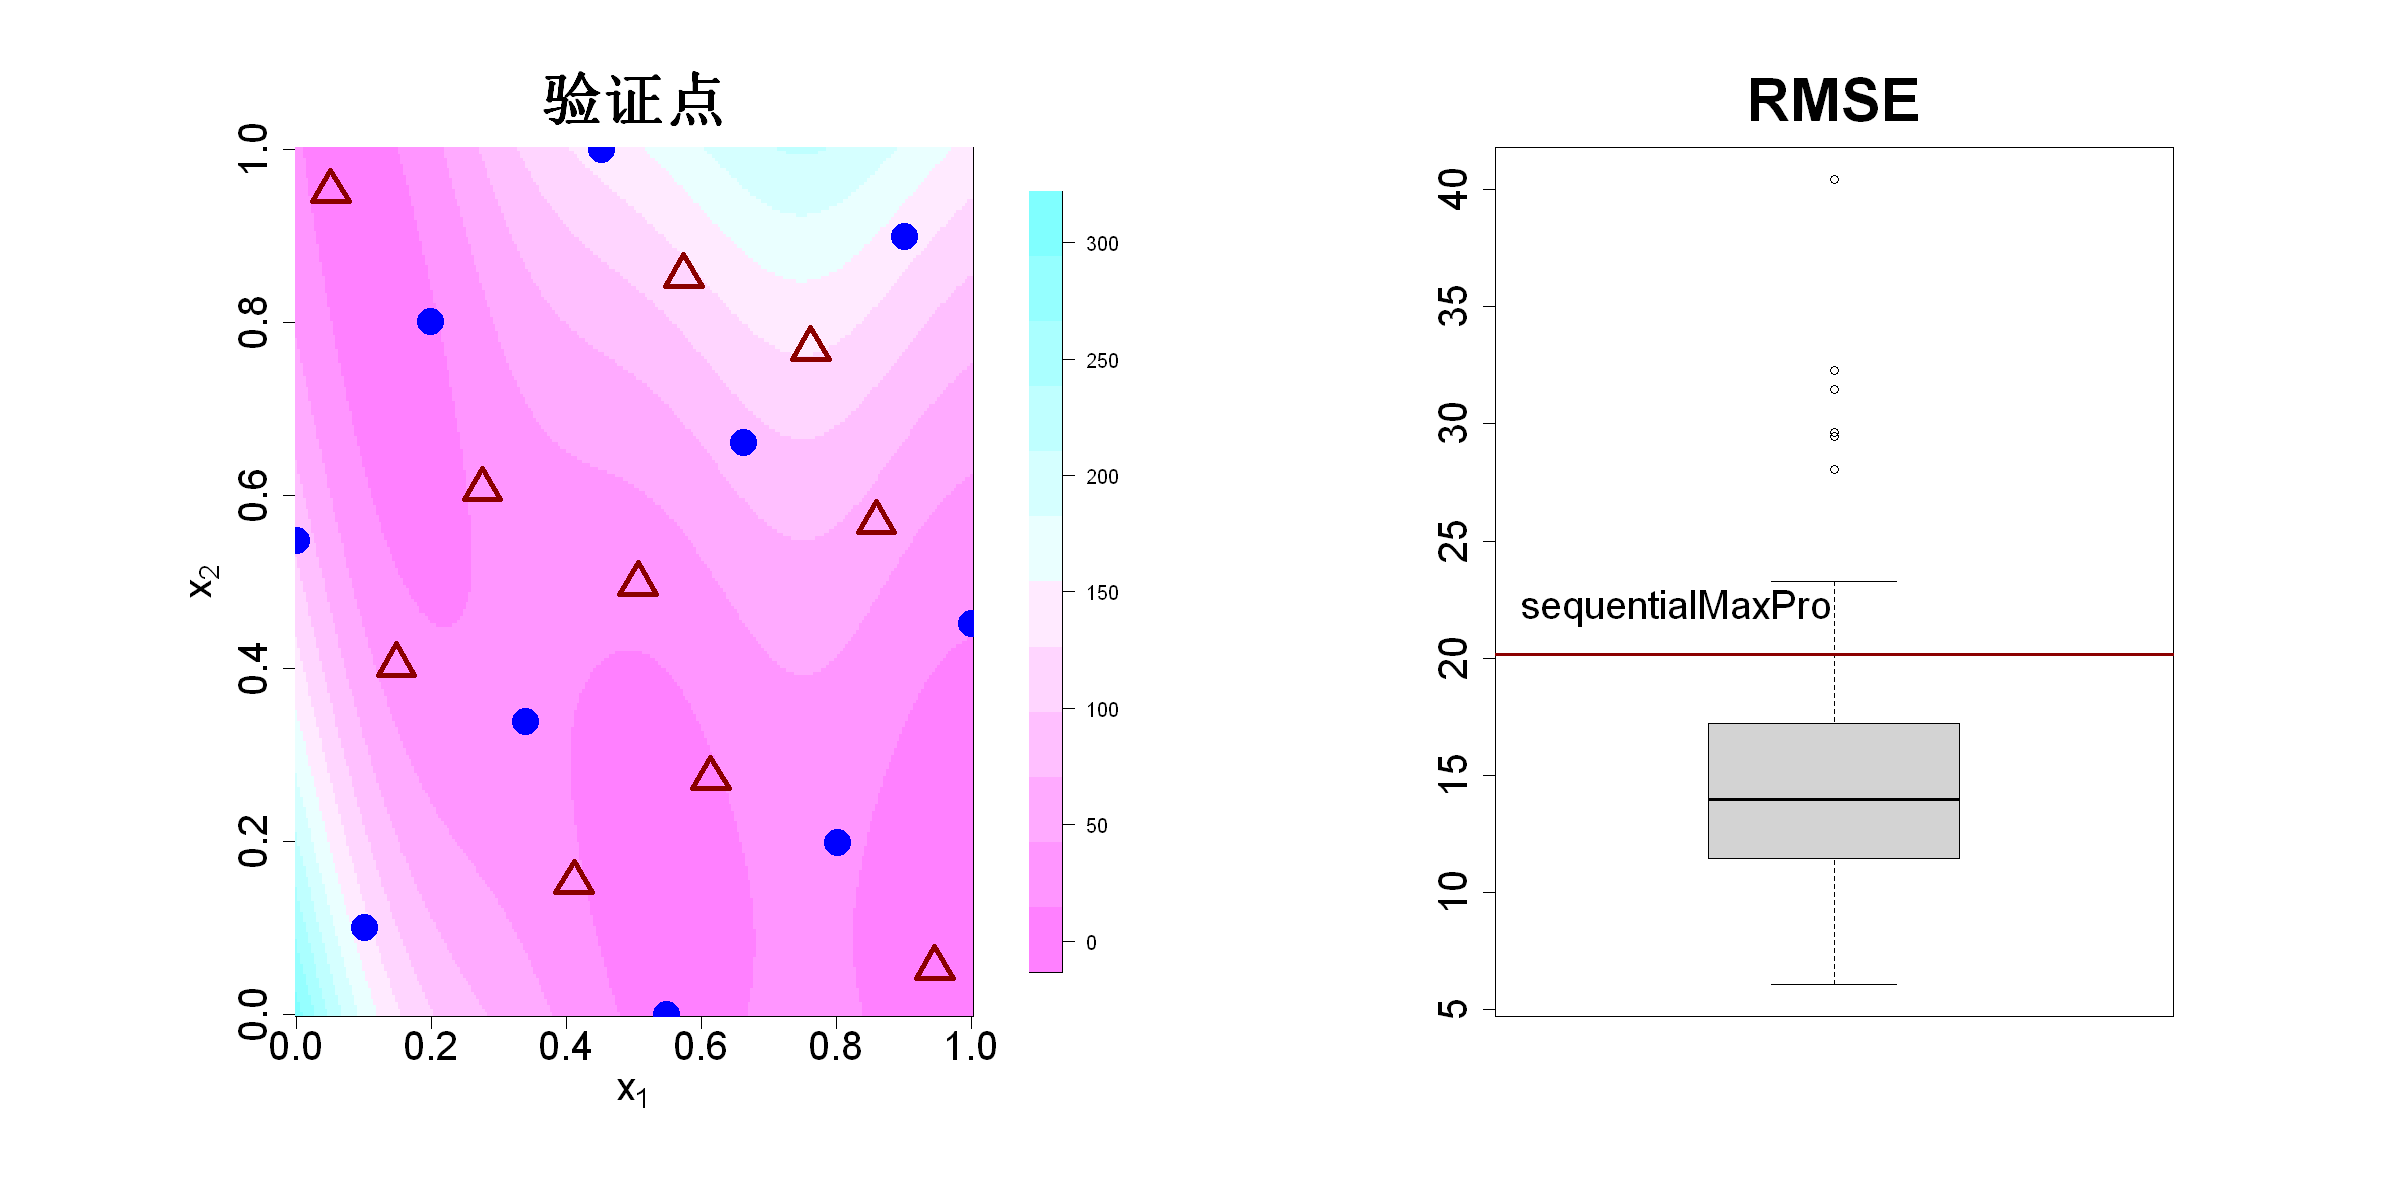

In [ ]:
options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
branin=function(x){
    x1=x[1]*15-5
    x2=x[2]*15
    (x2-5.1/(4*pi^2)*(x1^2)+5/pi*x1-6)^2+10*(1-1/(8*pi))*cos(x1)+10
}
p=2;n=10
set.seed(1)
library(SFDesign)
D=maxpro.optim(maxproLHD(n,p)$design)$design
y=apply(D,1,branin)
library(MaxPro)
A=MaxProAugment(ExistDesign=D,CandDesign=CandPoints(N=10000,2),nNew=10)$Design[(n+1):20,]
true=apply(A,1,branin)
library(rkriging)
a=Fit.Kriging(D,y,kernel.parameters=list(type="Gaussian"))
pred=Predict.Kriging(a,A)$mean
rmse0=sqrt(mean((pred-true)^2))

N.plot=250
p1=seq(0,1,length=N.plot)
p2=seq(0,1,length=N.plot)
fc=matrix(0,N.plot,N.plot)
for(i in 1:N.plot){
    for(j in 1:N.plot)fc[i,j]=branin(c(p1[i],p2[j]))
}

library(fields)
imagePlot(p1,p2,fc,xlab=expression(x[1]),ylab=expression(x[2]),col=cm.colors(12,rev=TRUE),main="验证点",cex.main=3,cex.lab=2,cex.axis=2)
points(D,pch=16,col="blue",cex=3)
points(A,pch=2,col="darkred",lwd=4,cex=3)

rmse=rep(0,100)
for(i in 1:100){
    u=matrix(runif(p*10),nrow=10,ncol=p)
    pred=Predict.Kriging(a,u)$mean
    true=apply(u,1,branin)
    rmse[i]=sqrt(mean((pred-true)^2))
}
boxplot(rmse,main="RMSE",cex.main=3,cex.axis=2)
abline(h=rmse0,col="darkred",lwd=3)
text(.75,rmse0+2,"sequentialMaxPro",cex=2)
par(mfrow=c(1,1))